In [5]:
import os
import sys
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import joblib

sys.path.append('..')
from utils import EALSTM_helper
from utils.EALSTM_helper import EALSTM, EASequenceDataset, make_sequences_with_static, evaluate

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## Configuration

Entity-Aware LSTM for streamflow prediction in the Uinta Basin.
Static catchment attributes (area, elevation, slope, land cover) modulate
the LSTM input gate, allowing the model to condition predictions on basin characteristics.

Following Kratzert et al. (2019):
- Dynamic inputs: meteorological forcing + SWE (time-varying)
- Static inputs: catchment attributes (constant per basin)
- Spatial holdout: one basin withheld entirely for testing

Split strategy:
- Train: 1980–2016 (7 training sites)
- Validation: 2017–2024 (7 training sites)  
- Spatial test: held-out site, all years

In [6]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Paths
FILE_PATH  = "../data/merged/merged_all_sites.csv"
MODEL_DIR  = "model/EALSTM/"
DATE_COL   = "Date"
TARGET_COL = "flow_cms"

# Spatial holdout
TEST_SITE = "10154200"  # Provo River

# Temporal split
TRAIN_END_YEAR = 2016
VAL_START_YEAR = 2017

# Feature columns
DYNAMIC_COLS = [
    'SWE_cm_mean', 'prcp_mm_day', 'tmean_C',
    'tmax_C', 'tmin_C', 'srad_W_m2', 'vp_Pa', 'dayl_s'
]

STATIC_COLS = [
    'Area_km2', 'Average_Elevation_m',
    'Average_Slope', 'Evergreen_Forest'
]

# Hyperparameters
LOOKBACK_DAYS = 30
BATCH_SIZE    = 1024
EPOCHS        = 50
PATIENCE      = 8
LEARNING_RATE = 1e-3
HIDDEN_SIZE   = 32
DROPOUT       = 0.2

## Load and Preview Data

In [7]:
df = pd.read_csv(FILE_PATH)

# Clean column names
clean_cols = []
for c in df.columns:
    c = str(c).strip().replace('"', '')
    c = ''.join(ch if ch.isalnum() else '_' for ch in c)
    while '__' in c:
        c = c.replace('__', '_')
    c = c.strip('_')
    clean_cols.append(c)
df.columns = clean_cols

# Parse date and sort
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df['gage_id'] = df['gage_id'].astype(str)
df = df.sort_values(['gage_id', DATE_COL]).reset_index(drop=True)

print('Total rows:', len(df))
print('Sites:', sorted(df['gage_id'].unique()))
print('Date range:', df[DATE_COL].min().date(), 'to', df[DATE_COL].max().date())
df.head()

Total rows: 113627
Sites: ['10011500', '10128500', '10154200', '9217900', '9266500', '9289500', '9292000', '9299500']
Date range: 1980-01-01 to 2024-12-30


,Date,gage_id,SWE_cm_mean,dayl_s,prcp_mm_day,srad_W_m2,tmax_C,tmin_C,vp_Pa,tmean_C,...,Mixed_Forest,Shrub_Scrub,Grassland_Herbaceous,Unknown,Woody_Wetlands,Emergent_Herbaceous_Wetlands,Developed_High_Intensity,Perennial_Ice_Snow,site_no,flow_cms
0,1980-01-01,10011500,13.72,32870.05,0.00,162.57,0.22,-7.22,355.51,-3.500,...,5.918358,17.225756,0.444367,0.0,2.426592,0.124161,0.002178,0.0,10011500.0,0.764554
1,1980-01-02,10011500,13.72,32912.67,0.00,201.19,-1.32,-11.08,262.44,-6.200,...,5.918358,17.225756,0.444367,0.0,2.426592,0.124161,0.002178,0.0,10011500.0,0.764554
2,1980-01-03,10011500,13.72,32958.77,0.00,271.35,0.16,-17.42,155.70,-8.630,...,5.918358,17.225756,0.444367,0.0,2.426592,0.124161,0.002178,0.0,10011500.0,0.821187
3,1980-01-04,10011500,13.72,33008.32,0.00,170.77,3.01,-4.83,426.56,-0.910,...,5.918358,17.225756,0.444367,0.0,2.426592,0.124161,0.002178,0.0,10011500.0,0.792870
4,1980-01-05,10011500,13.72,33061.29,5.39,193.52,6.02,-8.07,332.80,-1.025,...,5.918358,17.225756,0.444367,0.0,2.426592,0.124161,0.002178,0.0,10011500.0,0.792870


In [8]:
# Verify all required columns are present
missing_dynamic = [c for c in DYNAMIC_COLS if c not in df.columns]
missing_static  = [c for c in STATIC_COLS  if c not in df.columns]

print("Missing dynamic cols:", missing_dynamic)
print("Missing static cols: ", missing_static)
print("\nStatic attribute values per site:")
print(df.groupby('gage_id')[STATIC_COLS].first().round(2))

Missing dynamic cols: []
Missing static cols:  []

Static attribute values per site:
          Area_km2  Average_Elevation_m  Average_Slope  Evergreen_Forest
gage_id                                                                 
10011500    797.52              2958.48           0.25             51.36
10128500    735.83              2756.08           0.36             54.72
10154200    734.28              2760.73           0.23             56.82
9217900     586.30              3178.27           0.28             59.26
9266500     460.52              2879.06           0.20             73.94
9289500     355.67              3280.18           0.30             52.10
9292000     473.27              3260.16           0.31             50.08
9299500     529.43              3126.58           0.26             61.53


In [9]:
# Fill missing values per site
all_feature_cols = DYNAMIC_COLS + [TARGET_COL]
df[all_feature_cols] = (
    df.groupby('gage_id')[all_feature_cols]
    .transform(lambda x: x.interpolate(method='linear', limit_direction='both').ffill().bfill())
)

# Fill any remaining static attribute NaNs with 0
df[STATIC_COLS] = df[STATIC_COLS].fillna(0)

print("Missing values remaining:")
print(df[DYNAMIC_COLS + STATIC_COLS + [TARGET_COL]].isnull().sum())

Missing values remaining:
SWE_cm_mean            0
prcp_mm_day            0
tmean_C                0
tmax_C                 0
tmin_C                 0
srad_W_m2              0
vp_Pa                  0
dayl_s                 0
Area_km2               0
Average_Elevation_m    0
Average_Slope          0
Evergreen_Forest       0
flow_cms               0
dtype: int64


## Spatial and Temporal Splits

The held-out site is withheld entirely from training.
The remaining sites are split temporally into train and validation sets.

In [10]:
# Spatial split
spatial_test_df = df[df['gage_id'] == TEST_SITE].copy()
train_sites_df  = df[df['gage_id'] != TEST_SITE].copy()

# Temporal split on training sites
train_sites_df['year'] = train_sites_df[DATE_COL].dt.year
train_df = train_sites_df[train_sites_df['year'] <= TRAIN_END_YEAR].copy()
val_df   = train_sites_df[train_sites_df['year'] >= VAL_START_YEAR].copy()

print(f"Spatial test site ({TEST_SITE}): {len(spatial_test_df)} rows")
print(f"Training sites: {sorted(train_sites_df['gage_id'].unique())}")
print(f"Train rows:     {len(train_df)}")
print(f"Val rows:       {len(val_df)}")
print(f"Test rows:      {len(spatial_test_df)}")

Spatial test site (10154200): 16436 rows
Training sites: ['10011500', '10128500', '9217900', '9266500', '9289500', '9292000', '9299500']
Train rows:     76744
Val rows:       20447
Test rows:      16436


## Scale Features

Three separate scalers:
- **feature_scaler**: dynamic met + SWE features
- **static_scaler**: static catchment attributes
- **target_scaler**: streamflow target

All scalers are fit on training data only to prevent data leakage.

In [11]:
os.makedirs(MODEL_DIR, exist_ok=True)

feature_scaler = MinMaxScaler()
static_scaler  = MinMaxScaler()
target_scaler  = MinMaxScaler()

# Fit on training data only
feature_scaler.fit(train_df[DYNAMIC_COLS])
static_scaler.fit(train_df[STATIC_COLS])
target_scaler.fit(train_df[[TARGET_COL]])

# Save scalers
joblib.dump(feature_scaler, f"{MODEL_DIR}feature_scaler.pkl")
joblib.dump(static_scaler,  f"{MODEL_DIR}static_scaler.pkl")
joblib.dump(target_scaler,  f"{MODEL_DIR}target_scaler.pkl")

# Apply scaling to all splits
def scale_split(df):
    df = df.copy()
    df[DYNAMIC_COLS] = feature_scaler.transform(df[DYNAMIC_COLS])
    df[STATIC_COLS]  = static_scaler.transform(df[STATIC_COLS])
    df[TARGET_COL]   = target_scaler.transform(df[[TARGET_COL]])
    return df

train_scaled = scale_split(train_df)
val_scaled   = scale_split(val_df)
test_scaled  = scale_split(spatial_test_df)

print("Scaling complete.")

Scaling complete.


## Create Sequences

Using `make_sequences_with_static()` which processes each site separately,
avoiding sequences that bleed across basin boundaries.

In [12]:
X_train, X_train_static, y_train, d_train = make_sequences_with_static(
    train_scaled, DATE_COL, DYNAMIC_COLS, STATIC_COLS, TARGET_COL, LOOKBACK_DAYS)

X_val, X_val_static, y_val, d_val = make_sequences_with_static(
    val_scaled, DATE_COL, DYNAMIC_COLS, STATIC_COLS, TARGET_COL, LOOKBACK_DAYS)

X_test, X_test_static, y_test, d_test = make_sequences_with_static(
    test_scaled, DATE_COL, DYNAMIC_COLS, STATIC_COLS, TARGET_COL, LOOKBACK_DAYS)

print('Train shape:  ', X_train.shape, X_train_static.shape, y_train.shape)
print('Val shape:    ', X_val.shape,   X_val_static.shape,   y_val.shape)
print('Test shape:   ', X_test.shape,  X_test_static.shape,  y_test.shape)

Train shape:   (76534, 30, 8) (76534, 4) (76534,)
Val shape:     (20237, 30, 8) (20237, 4) (20237,)
Test shape:    (16406, 30, 8) (16406, 4) (16406,)


In [13]:
train_loader = DataLoader(EASequenceDataset(X_train, X_train_static, y_train), batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(EASequenceDataset(X_val,   X_val_static,   y_val),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(EASequenceDataset(X_test,  X_test_static,  y_test),  batch_size=BATCH_SIZE, shuffle=False)

## Define EA-LSTM Model

The key difference from a standard LSTM is the entity-aware input gate:
- Standard LSTM: all gates computed from dynamic inputs at every timestep
- EA-LSTM: input gate computed **once** from static attributes per basin

This allows the model to learn a different "personality" for each basin
based on its physical characteristics.

In [14]:
model = EALSTM(
    dynamic_input_size = len(DYNAMIC_COLS),
    static_input_size  = len(STATIC_COLS),
    hidden_size        = HIDDEN_SIZE,
    dropout            = DROPOUT
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

EALSTM(
  (lstm): LSTM(8, 32, batch_first=True)
  (W_i): Linear(in_features=4, out_features=32, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

Trainable parameters: 5,569


## Train Model

In [15]:
best_val_loss    = np.inf
best_state       = None
patience_counter = 0
history          = {'train_loss': [], 'val_loss': []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    batch_losses = []

    for xb_dynamic, xb_static, yb in train_loader:
        xb_dynamic = xb_dynamic.to(device)
        xb_static  = xb_static.to(device)
        yb         = yb.to(device)

        optimizer.zero_grad()
        pred = model(xb_dynamic, xb_static)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    train_loss = float(np.mean(batch_losses))
    val_loss, _, _ = evaluate(model, criterion, device, val_loader)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    print(f"Epoch {epoch:03d} | train loss = {train_loss:.5f} | val loss = {val_loss:.5f}")

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_state       = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

if best_state is not None:
    model.load_state_dict(best_state)
    torch.save(best_state, f"{MODEL_DIR}best_model_ealstm.pt")
    print("Best model saved.")

Epoch 001 | train loss = 0.00575 | val loss = 0.00459
Epoch 002 | train loss = 0.00466 | val loss = 0.00390
Epoch 003 | train loss = 0.00399 | val loss = 0.00376
Epoch 004 | train loss = 0.00387 | val loss = 0.00414
Epoch 005 | train loss = 0.00389 | val loss = 0.00361
Epoch 006 | train loss = 0.00340 | val loss = 0.00401
Epoch 007 | train loss = 0.00359 | val loss = 0.00352
Epoch 008 | train loss = 0.00300 | val loss = 0.00353
Epoch 009 | train loss = 0.00290 | val loss = 0.00351
Epoch 010 | train loss = 0.00283 | val loss = 0.00349
Epoch 011 | train loss = 0.00276 | val loss = 0.00349
Epoch 012 | train loss = 0.00270 | val loss = 0.00349
Epoch 013 | train loss = 0.00263 | val loss = 0.00350
Epoch 014 | train loss = 0.00261 | val loss = 0.00349
Epoch 015 | train loss = 0.00255 | val loss = 0.00341
Epoch 016 | train loss = 0.00251 | val loss = 0.00337
Epoch 017 | train loss = 0.00249 | val loss = 0.00335
Epoch 018 | train loss = 0.00250 | val loss = 0.00325
Epoch 019 | train loss = 0.0

## Training History

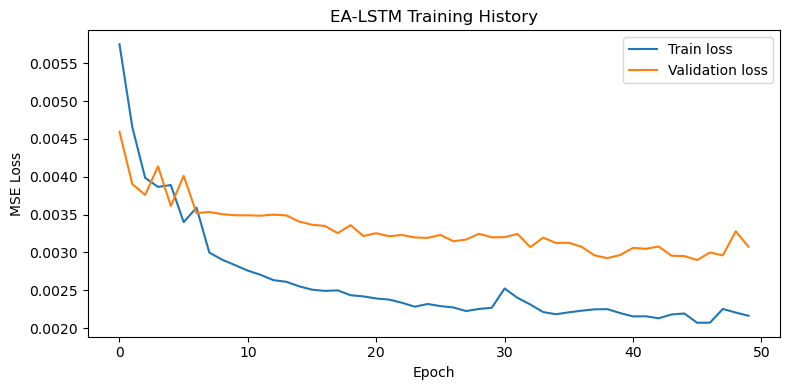

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='Train loss')
plt.plot(history['val_loss'],   label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('EA-LSTM Training History')
plt.legend()
plt.tight_layout()
plt.show()

## Spatial Generalization Test

Evaluating on the held-out site — the model has never seen this basin during training.

In [17]:
test_loss, test_pred_scaled, test_obs_scaled = evaluate(model, criterion, device, test_loader)

pred_flow = target_scaler.inverse_transform(test_pred_scaled.reshape(-1, 1)).ravel()
obs_flow  = target_scaler.inverse_transform(test_obs_scaled.reshape(-1, 1)).ravel()

rmse = math.sqrt(mean_squared_error(obs_flow, pred_flow))
mae  = mean_absolute_error(obs_flow, pred_flow)
r2   = r2_score(obs_flow, pred_flow)

print(f"Spatial Test Site: {TEST_SITE}")
print(f"Test MSE (scaled): {test_loss:.5f}")
print(f"RMSE:              {rmse:.4f} cms")
print(f"MAE:               {mae:.4f} cms")
print(f"R² / NSE:          {r2:.4f}")

Spatial Test Site: 10154200
Test MSE (scaled): 0.00410
RMSE:              5.6789 cms
MAE:               2.5171 cms
R² / NSE:          0.6697


## Time Series

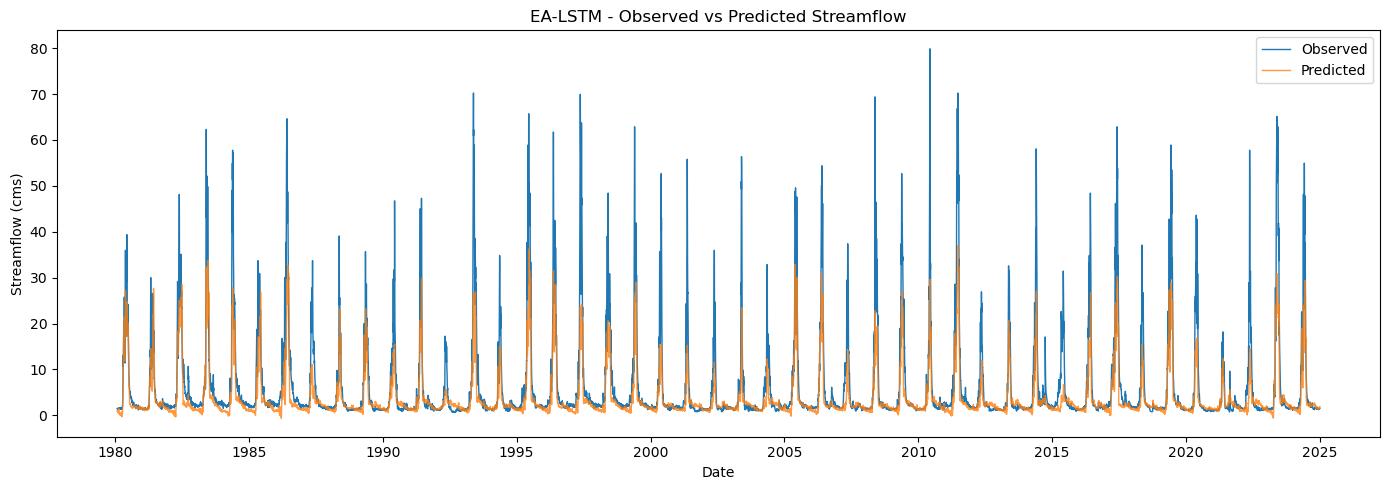

In [18]:
plt.figure(figsize=(14, 5))
plt.plot(d_test, obs_flow,  label='Observed',  linewidth=1)
plt.plot(d_test, pred_flow, label='Predicted', linewidth=1, alpha=0.8)
plt.xlabel('Date')
plt.ylabel('Streamflow (cms)')
plt.title(f'EA-LSTM - Observed vs Predicted Streamflow')
plt.legend()
plt.tight_layout()
plt.show()

In [1]:
# Zoom: Water Years 2010-2011
mask = (pd.to_datetime(d_test) >= '2009-10-01') & (pd.to_datetime(d_test) <= '2011-09-30')
d_zoom = pd.to_datetime(d_test)[mask]
obs_zoom  = obs_flow[mask]
pred_zoom = pred_flow[mask]

plt.figure(figsize=(14, 5))
plt.plot(d_zoom, obs_zoom,  label='Observed',  linewidth=1)
plt.plot(d_zoom, pred_zoom, label='Predicted', linewidth=1, alpha=0.8)
plt.xlabel('Date')
plt.ylabel('Streamflow (cms)')
plt.title('EA-LSTM - Observed vs Predicted Streamflow (WY 2010–2011)')
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'pd' is not defined

## Scatter


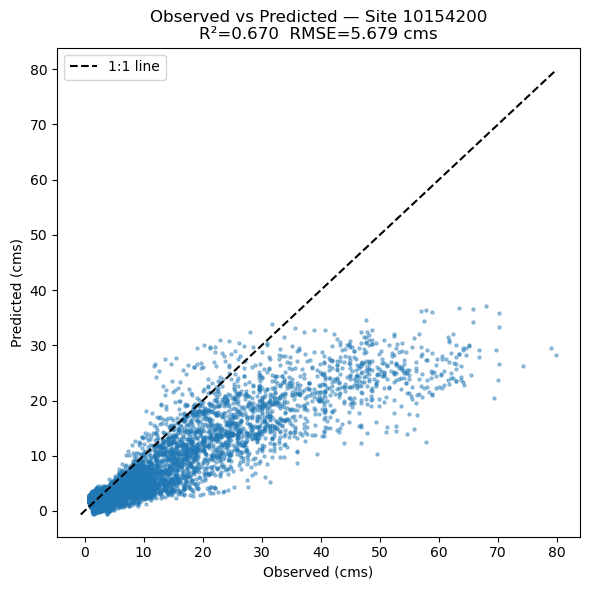

In [19]:
plt.figure(figsize=(6, 6))
plt.scatter(obs_flow, pred_flow, alpha=0.4, s=5)
lims = [min(obs_flow.min(), pred_flow.min()), max(obs_flow.max(), pred_flow.max())]
plt.plot(lims, lims, 'k--', label='1:1 line')
plt.xlabel('Observed (cms)')
plt.ylabel('Predicted (cms)')
plt.title(f'Observed vs Predicted — Site {TEST_SITE}\nR²={r2:.3f}  RMSE={rmse:.3f} cms')
plt.legend()
plt.tight_layout()
plt.show()

## Performance Summary — All Sites

In [20]:
site_results = []

for gage_id in sorted(train_sites_df['gage_id'].unique()):
    site_df = train_sites_df[train_sites_df['gage_id'] == gage_id].copy()
    site_scaled = scale_split(site_df)

    X_site, X_site_static, y_site, d_site = make_sequences_with_static(
        site_scaled, DATE_COL, DYNAMIC_COLS, STATIC_COLS, TARGET_COL, LOOKBACK_DAYS)

    site_loader = DataLoader(
        EASequenceDataset(X_site, X_site_static, y_site),
        batch_size=BATCH_SIZE, shuffle=False)

    site_loss, site_pred_scaled, site_obs_scaled = evaluate(model, criterion, device, site_loader)

    site_pred = target_scaler.inverse_transform(site_pred_scaled.reshape(-1, 1)).ravel()
    site_obs  = target_scaler.inverse_transform(site_obs_scaled.reshape(-1, 1)).ravel()

    site_results.append({
        "gage_id": gage_id,
        "split":   "train/val",
        "NSE":     r2_score(site_obs, site_pred),
        "RMSE":    math.sqrt(mean_squared_error(site_obs, site_pred)),
        "MAE":     mean_absolute_error(site_obs, site_pred),
    })

# Add spatial test site
site_results.append({
    "gage_id": TEST_SITE,
    "split":   "spatial test (held out)",
    "NSE":     r2,
    "RMSE":    rmse,
    "MAE":     mae,
})

results_df = pd.DataFrame(site_results).set_index("gage_id")
print(results_df.round(3))
results_df.round(3).to_csv(f"../data/ealstm_performance_summary.csv")

                            split    NSE   RMSE    MAE
gage_id                                               
10011500                train/val  0.475  6.725  2.663
10128500                train/val  0.420  6.940  2.710
9217900                 train/val  0.589  5.186  2.293
9266500                 train/val  0.688  2.459  1.643
9289500                 train/val  0.642  3.241  1.858
9292000                 train/val  0.710  2.436  1.640
9299500                 train/val  0.764  2.226  1.309
10154200  spatial test (held out)  0.670  5.679  2.517


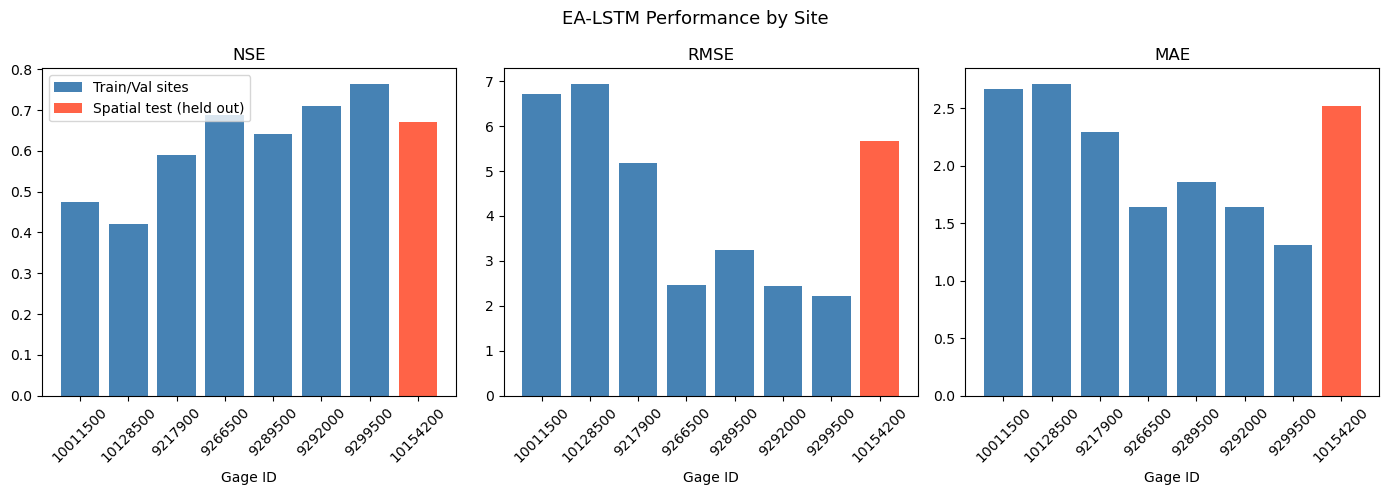

In [21]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ["NSE", "RMSE", "MAE"]
for ax, metric in zip(axes, metrics):
    colors = ["steelblue" if s == "train/val" else "tomato"
              for s in results_df["split"]]
    ax.bar(results_df.index, results_df[metric], color=colors)
    ax.set_title(metric)
    ax.set_xlabel("Gage ID")
    ax.tick_params(axis='x', rotation=45)

legend_elements = [
    Patch(facecolor="steelblue", label="Train/Val sites"),
    Patch(facecolor="tomato",    label="Spatial test (held out)")
]
axes[0].legend(handles=legend_elements)

plt.suptitle("EA-LSTM Performance by Site", fontsize=13)
plt.tight_layout()
plt.show()